In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris


In [2]:
from data_science.styles import apply_luna_style


In [3]:
apply_luna_style()

## Data


In [4]:
iris = load_iris()

data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

## Basic Statistics


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB


In [6]:
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
data.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Data visualization


### Countplot


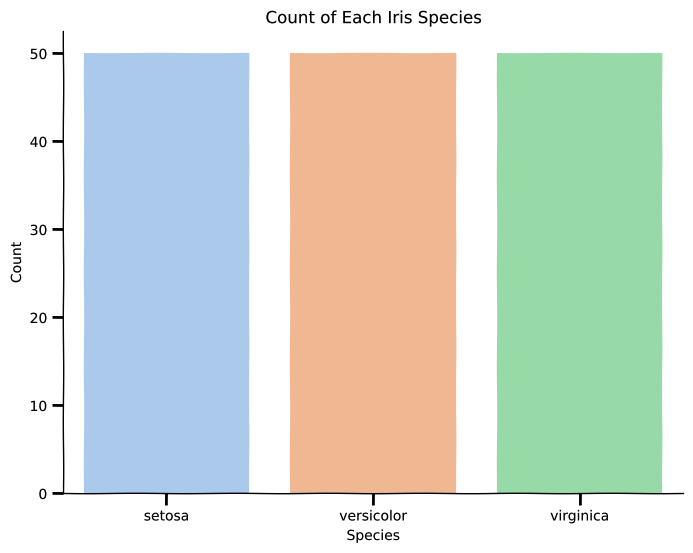

In [8]:
plt.figure(figsize=(8, 6))
sns.countplot(x='species', data=data, palette='pastel', hue='species')
sns.despine()
plt.title('Count of Each Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

### Histrogram


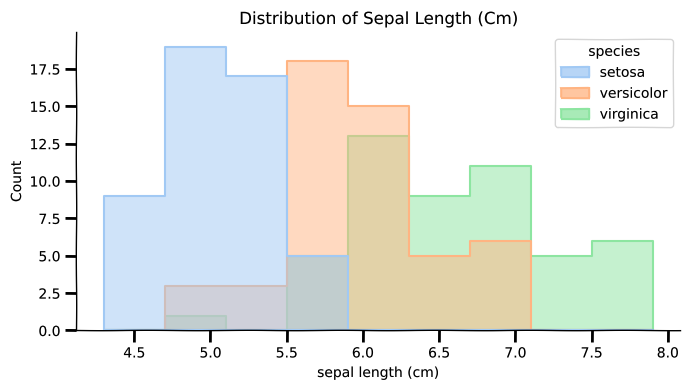

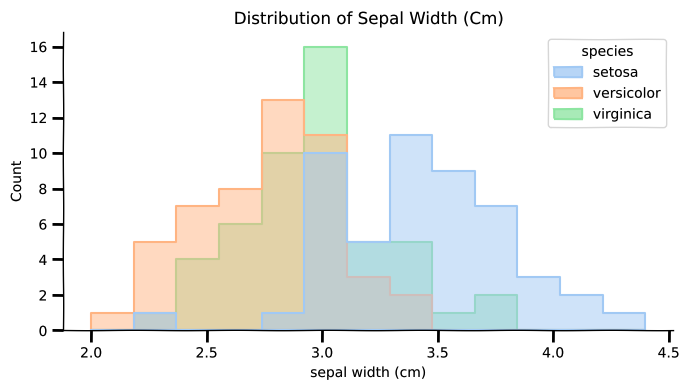

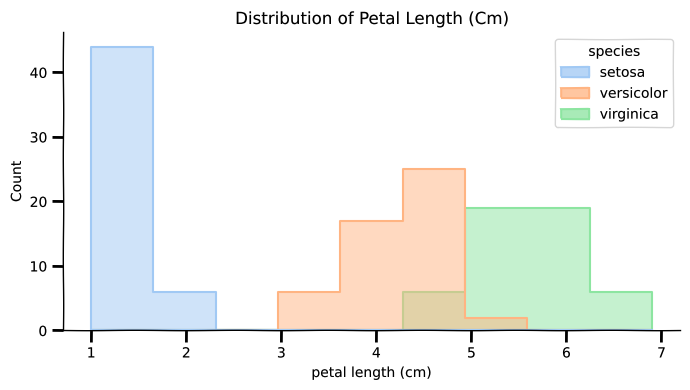

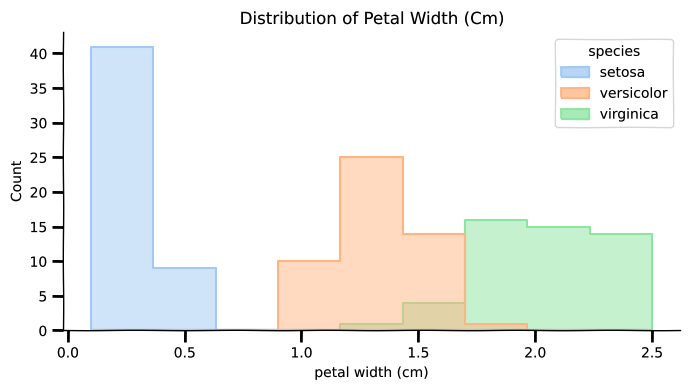

In [9]:
for feature in data.columns[:-1]:
    plt.figure(figsize=(7, 4))
    sns.histplot(
        data=data,
        x=feature,
        hue='species',
        fill=True,
        alpha=0.5,
        element='step',
        linewidth=1.5,
        common_norm=False,
        palette='pastel',
        legend=True,
        # kde=True,
        # hue_order=[1, 2, 3],
    )
    sns.despine()
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.title(f'Distribution of {feature.title()}')
    plt.tight_layout()
    plt.show()

### Boxplot


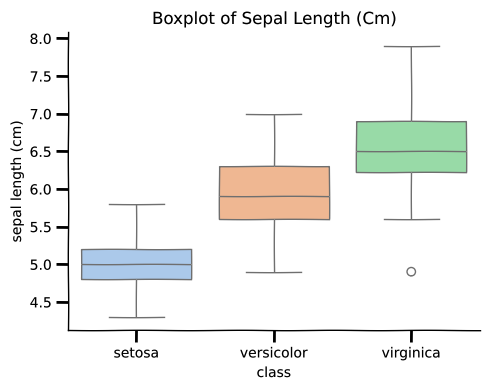

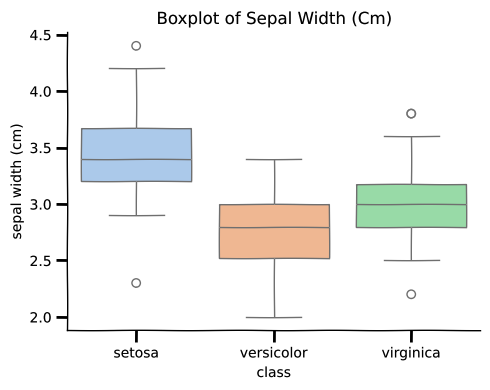

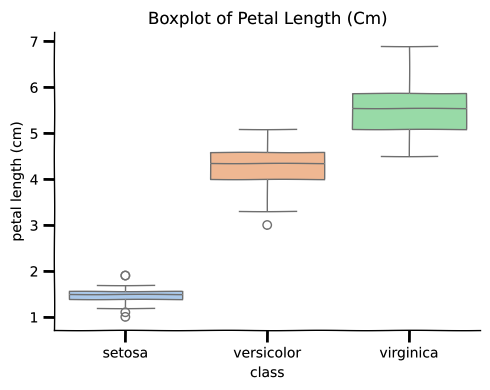

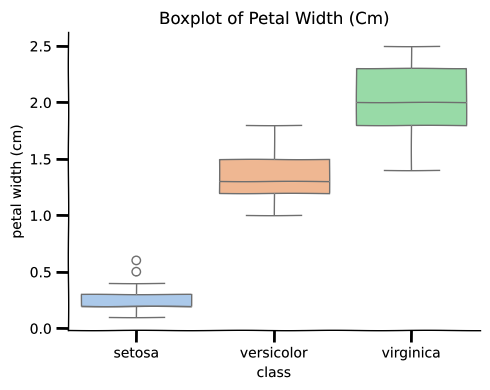

In [10]:
for feature in data.columns[:-1]:
    plt.figure(figsize=(5, 4))
    sns.boxplot(
        data=data,
        x='species',
        y=feature,
        palette='pastel',
        hue='species',
        # legend=True
    )
    sns.despine()
    plt.xlabel('class')
    plt.ylabel(feature)
    plt.title(f'Boxplot of {feature.title()}')
    plt.tight_layout()
    plt.show()

### Pairplot


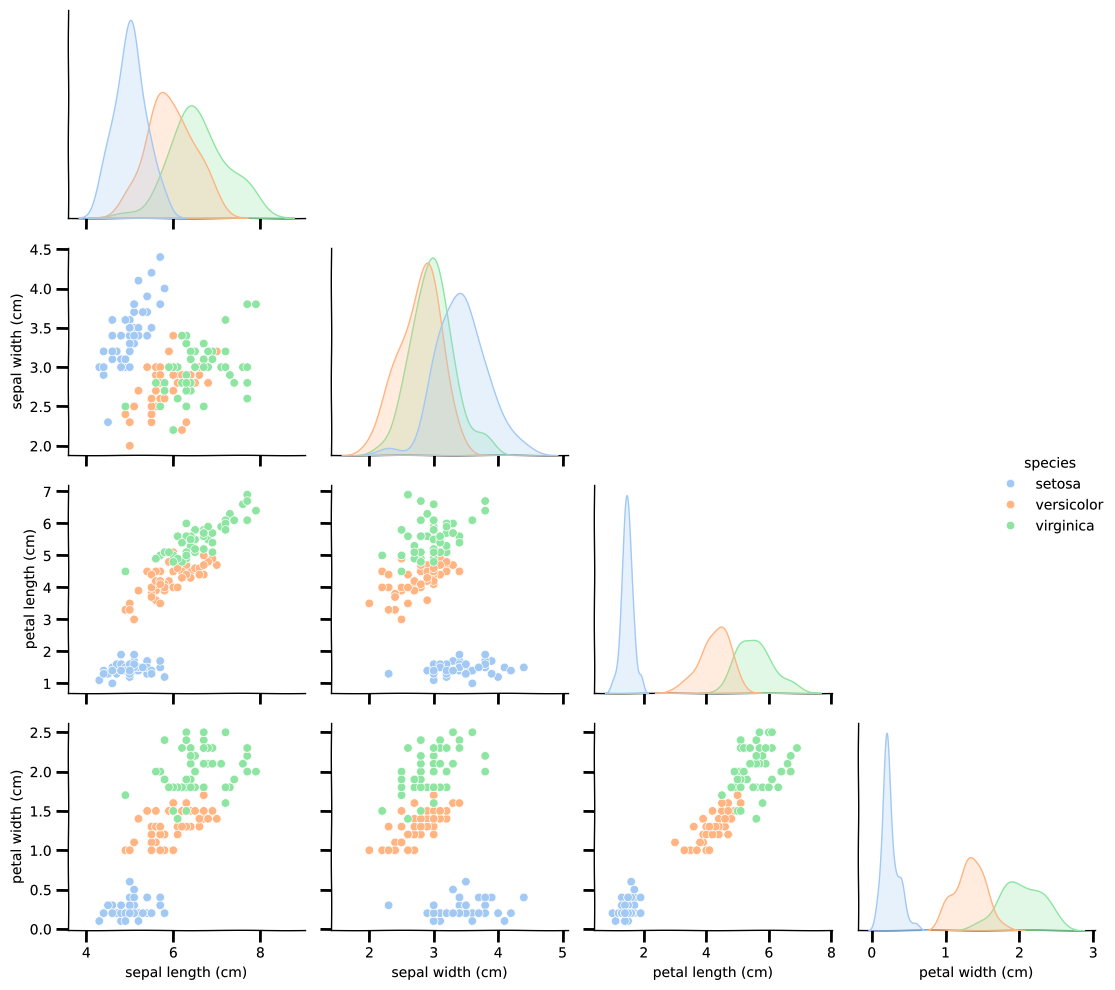

In [11]:
g = sns.pairplot(
    data,
    hue='species',
    palette='pastel',
    # diag_kind="kde",
    # hue_order=hue_order,
    corner=True,
)
sns.despine()
plt.tight_layout()
plt.show()

### Correlation Matrix


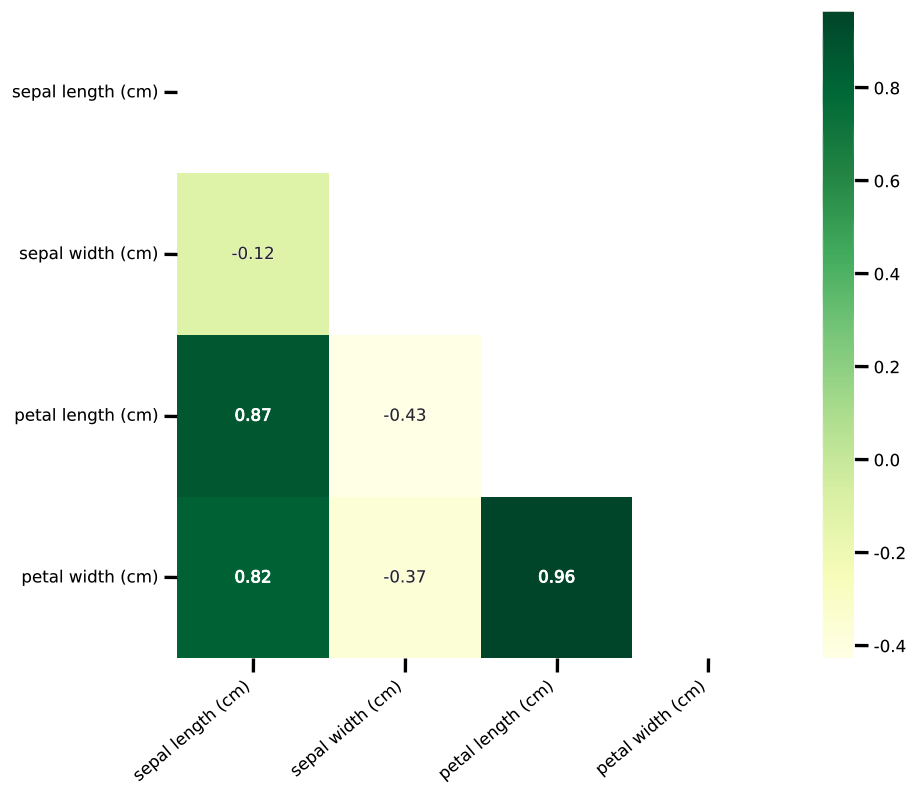

In [12]:
corr = data.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr))

plt.figure(figsize=(8, 6), dpi=120)
g = sns.heatmap(
    corr,
    annot=True,
    cmap='YlGn',
    mask=mask,
)

plt.tight_layout()
plt.grid(False)
plt.xticks(rotation=40, ha='right')
plt.yticks()

plt.show()